In [157]:
import numpy as np
import matplotlib.pyplot as plt

In [158]:
a, b = 1, 10
n, N = 7, 500

x = np.linspace(a, b, n+1)
# Jegliche Verteilung der Messstellen ist legal, solange sie die Knoten a und b beinhaltet. Hier z.B. mit den Chebyshev-Knoten:
k = n - np.arange(n-1) - 2
x = np.hstack(([a], a + 0.5*(b-a)*(np.cos((2*k+1) / (2 * (n-1)) * np.pi) + 1), [b]))
X = np.linspace(a, b, N)

In [159]:
f = lambda x: np.cos(x)*(1/x)
df = lambda x: -np.sin(x)*(1/x) - np.cos(x)*(1/x**2)

y = f(x)
Y = f(X)
dy = df(x)
dY = df(X)

In [160]:
j = np.argmin((x <= X[:,None]), axis=1) # findet das erste x grösser als X für jedes X
jl = (j - 1) % n

# Stelle sicher, dass kein wrap-around passiert:
j[j == 0] = n - 1
jl[j == 0] = n - 1
# print(j)


In [161]:
h = (np.roll(x, -1) - x)[:-1]
print(h)
t = (X - x[jl]) / h[jl] 

[0.15333378 1.1646857  2.01729481 2.32937141 2.01729481 1.1646857
 0.15333378]


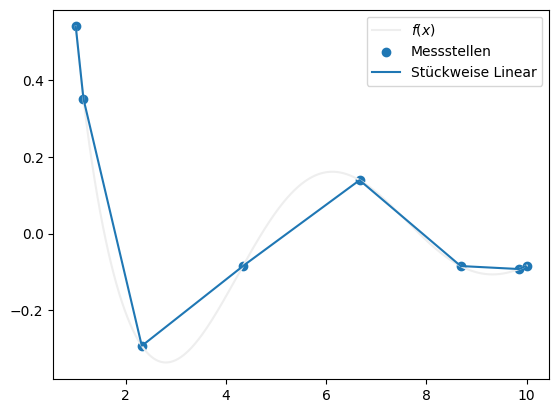

In [162]:
Z = (1 - t) * y[jl] + t * y[j]

plt.plot(X, Y, label=r"$f(x)$", color="#eeeeee")
plt.scatter(x, y, label="Messstellen")
plt.plot(X, Z, label="Stückweise Linear")
plt.legend()

## Kubische Splines: 
Konstruktion der Matrix

In [163]:
phi = lambda t: 3*t**2 - 2*t**3
psi = lambda t: t**3 - t**2

def cubic_hermite(y, dy):
    
    p = y[jl] * phi(1-t) + y[j] * phi(t)
    q = - dy[jl] * h[jl] * psi(1-t) + dy[j] * h[jl] * psi(t)

    return p + q

[[14.76064159  0.85860073  0.          0.          0.          0.        ]
 [ 0.85860073  2.7086282   0.49571337  0.          0.          0.        ]
 [ 0.          0.49571337  1.85002746  0.42930037  0.          0.        ]
 [ 0.          0.          0.42930037  1.85002746  0.49571337  0.        ]
 [ 0.          0.          0.          0.49571337  2.7086282   0.85860073]
 [ 0.          0.          0.          0.          0.85860073 14.76064159]]


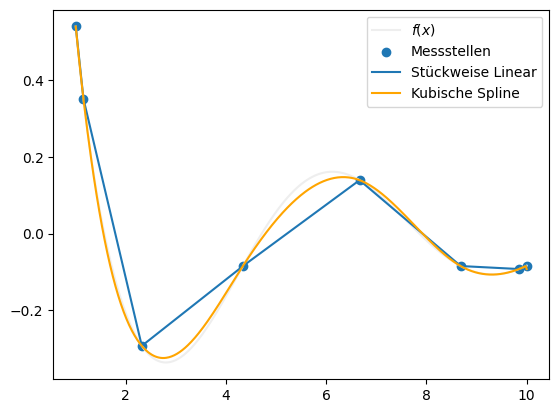

In [164]:
b_ = 1 / h
a_ = (2/h + 2/(np.roll(h, -1)))[:-1]

B0 = np.roll(np.diag(np.hstack(([0], b_[1:-1]))), -1, axis=1)
B1 = np.roll(np.diag(np.hstack((b_[1:-1], [0]))),  1, axis=1)
A = np.diag(a_) + B0 + B1
print(A)

# Konstruiere die rechte Seite der Gleichung
v = 3 * ((y[1:-1]-y[:-2])/(h[:-1]**2) + (y[2:]-y[1:-1])/(h[1:]**2))
v[0] -= df(a) * b_[0]   # Eingespannte Spline: df(a) und df(b) sind bekannt
v[-1] -= df(b) * b_[-1]

# Nutze QR-Zerlegung zum Lösen des LGS
Q, R = np.linalg.qr(A)
c = np.linalg.solve(R, Q.T @ v)
c = np.hstack(([df(a), c, df(b)]))

Z_Spline = cubic_hermite(y, c)

plt.plot(X, Y, label=r"$f(x)$", color="#eeeeee")
plt.scatter(x, y, label="Messstellen")
plt.plot(X, Z, label="Stückweise Linear")
plt.plot(X, Z_Spline, label="Kubische Spline", color="orange")
plt.legend()